In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import InterpolatedUnivariateSpline_SPF, EMP_PSF
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

2026-01-27 21:40:48.356159: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("../docs/tutorials/tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

18.578954605334317


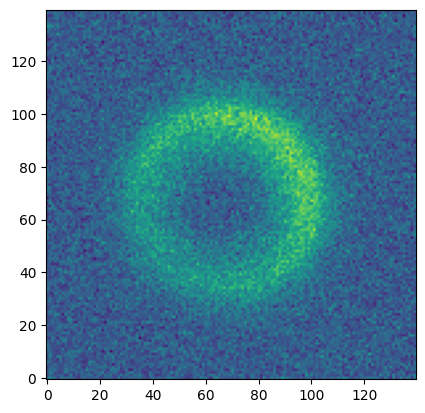

In [3]:
inc = 15
spec = "inc{}_spf0_betaneg".format(inc)
name = "inject_disk_{}.fits".format(spec)
target_img = jnp.array(fits.getdata(name))
plt.imshow(target_img,origin='lower')

H, W = target_img.shape
noise_patch = target_img[:20, W-20:W]
noise_level = jnp.std(noise_patch)
err_map = jnp.ones_like(target_img) * noise_level

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['inclination'] = inc+np.random.normal(3,2)
print(start_disk_params['inclination'])
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5


In [4]:
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.objective_functions import objective_model, objective_ll, objective_fit, Parameter_Index
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import *

opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)

opt.name = spec

In [5]:
opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
#opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used
opt.spf_params['knot_values'] = jnp.array(jnp.ones(opt.spf_params['num_knots'])*0.1)
opt.misc_params['flux_scaling'] = 1e4

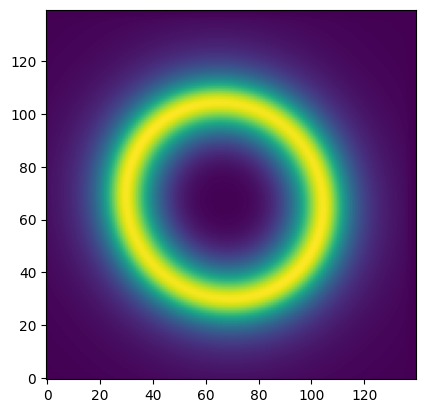

In [6]:
plt.imshow(opt.get_model(),origin='lower')

In [ ]:
fit_keys = ['sma', 'inclination', 'position_angle', 'beta','knot_values']
#logscaled_params = ['knot_values', 'inclination']
array_params = ['knot_values']
bounds = ([0, 0, 0,-5, np.zeros(opt.spf_params["num_knots"])],
          [150, 180, 400, 5, 1e4*np.ones(opt.spf_params["num_knots"])])

opt.scipy_optimize(fit_keys, [], array_params, target_img, err_map, method='Nelder-Mead', use_grad = False, disp_soln = True, iters = 2000)
optimal_image = opt.get_model()

/home/mihirkondapalli/anaconda3/envs/package-env/lib/python3.12/site-packages/grater_jax/optimization/optimize_framework.py:393: OptimizeWarning: Unknown solver options: ftol, gtol, eps
  soln = minimize(ll, init_x, method=method, jac=jac,


Optimization terminated successfully.
         Current function value: 3.140702
         Iterations: 1106
         Function evaluations: 1680
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3.140701677055107
             x: [ 3.261e+01  5.174e+01  4.820e+01  4.511e-01  2.592e-01
                  9.995e-02  3.875e-02  1.262e-03  3.766e-02]
           nit: 1106
          nfev: 1680
 final_simplex: (array([[ 3.261e+01,  5.174e+01, ...,  1.262e-03,
                         3.766e-02],
                       [ 3.261e+01,  5.174e+01, ...,  1.262e-03,
                         3.766e-02],
                       ...,
                       [ 3.261e+01,  5.174e+01, ...,  1.262e-03,
                         3.766e-02],
                       [ 3.261e+01,  5.174e+01, ...,  1.262e-03,
                         3.766e-02]], shape=(10, 9)), array([ 3.141e+00,  3.141e+00,  3.141e+00,  3.141e+00,
                        3.141e+00,  3.141e+00,

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': np.float64(32.612714083319275), 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(0.4510637115383406), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(51.742907509441864), 'position_angle': np.float64(48.20450571472611), 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.31861116, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.31861116, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([6.68886996, 2.57892167, 1.        , 0.03255633, 0.97184761],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(387.54814446, dtype=float64)}


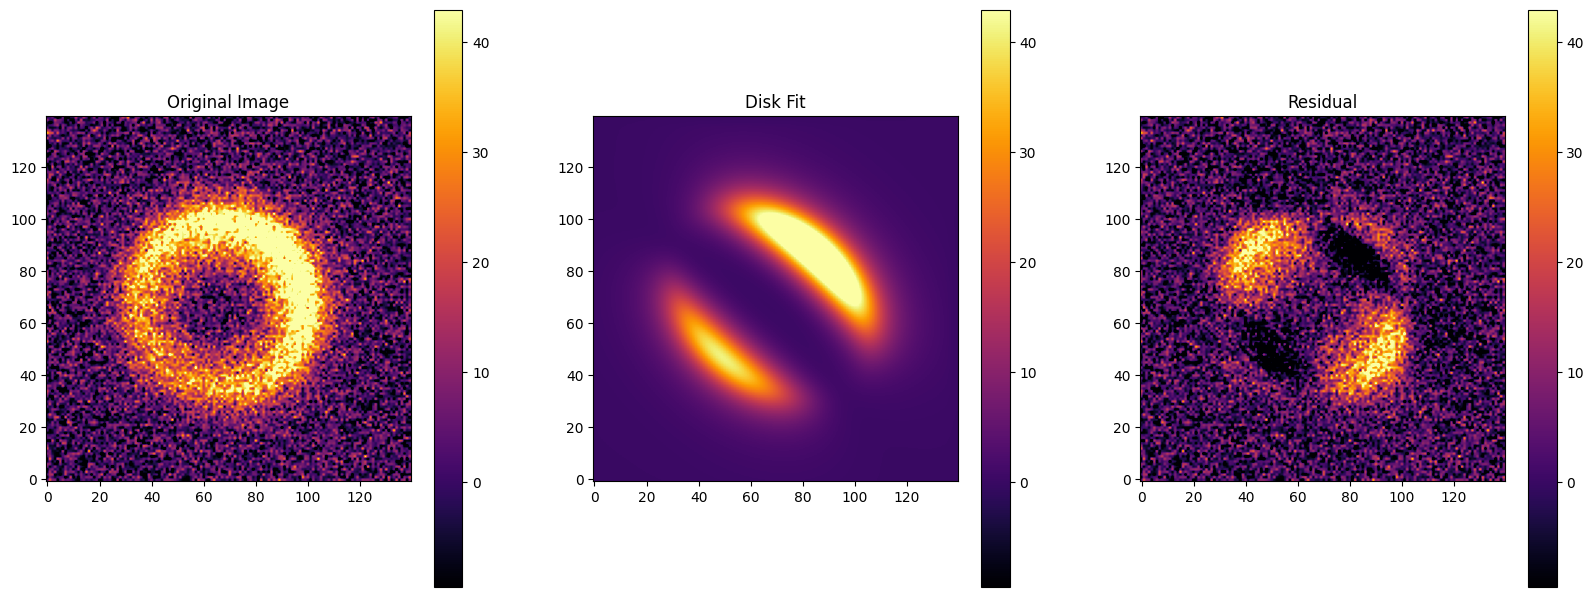

In [8]:
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image, 10)
vmax = np.nanpercentile(target_image, 95)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout
plt.savefig('{}_scipyminimize_img.png'.format(name))

inject_disk_inc15_spf0_betaneg.fits
inc15_spf0_betaneg
[ 71.42104539  80.83340804  90.          99.16659196 108.57895461]


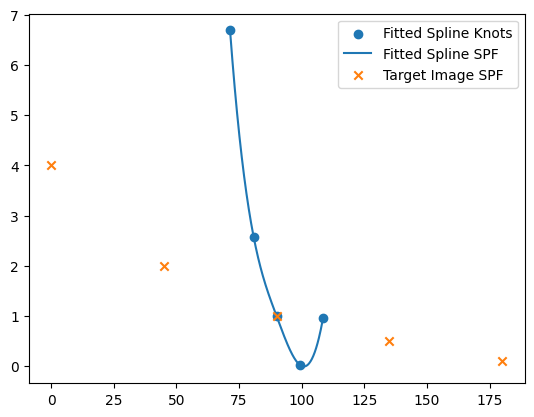

In [9]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.scatter(np.linspace(0,180,5),[4.0,2.0,1.0,0.5,0.1],marker='x',zorder=10)

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.savefig('{}_scipyminimize_spf.png'.format(name))

print(name)
print(opt.name)
print(knot_locs)

In [10]:
# For MCMC, spline values are log scaled, the optimizer class passes them in as log(spf_params) and they are exponated in the lambda expression, this evens out the markov chains
# helping MCMC work better

mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=50, burns=1,continue_from=True)

AttributeError: 'EnsembleSampler' object has no attribute '_previous_state'

Disk Params: {'accuracy': 0.005, 'alpha_in': 5, 'alpha_out': -5, 'sma': np.float64(24.718713632474397), 'e': 0.0, 'ksi0': 3.0, 'gamma': 2.0, 'beta': np.float64(-0.8211666845569132), 'rmin': 0.0, 'dens_at_r0': 1.0, 'inclination': np.float64(11.99602824441288), 'position_angle': np.float64(42.81667318794825), 'x_center': 70.0, 'y_center': 70.0, 'halfNbSlices': 25, 'omega': 0.0}
SPF Params: {'backscatt_bound': Array(-0.31540514, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.31540514, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.69985012, 1.25952017, 1.        , 0.76213582, 0.56947605],      dtype=float64), 'frontscatt_bound': 0.9}
PSF Params: {'scale_factor': 1.0, 'offset': 1.0}
Stellar PSF Params: None
Misc Params: {'distance': 50.0, 'pxInArcsec': 0.01414, 'nx': 140, 'ny': 140, 'halfNbSlices': 25, 'flux_scaling': Array(10237.09529393, dtype=float64)}


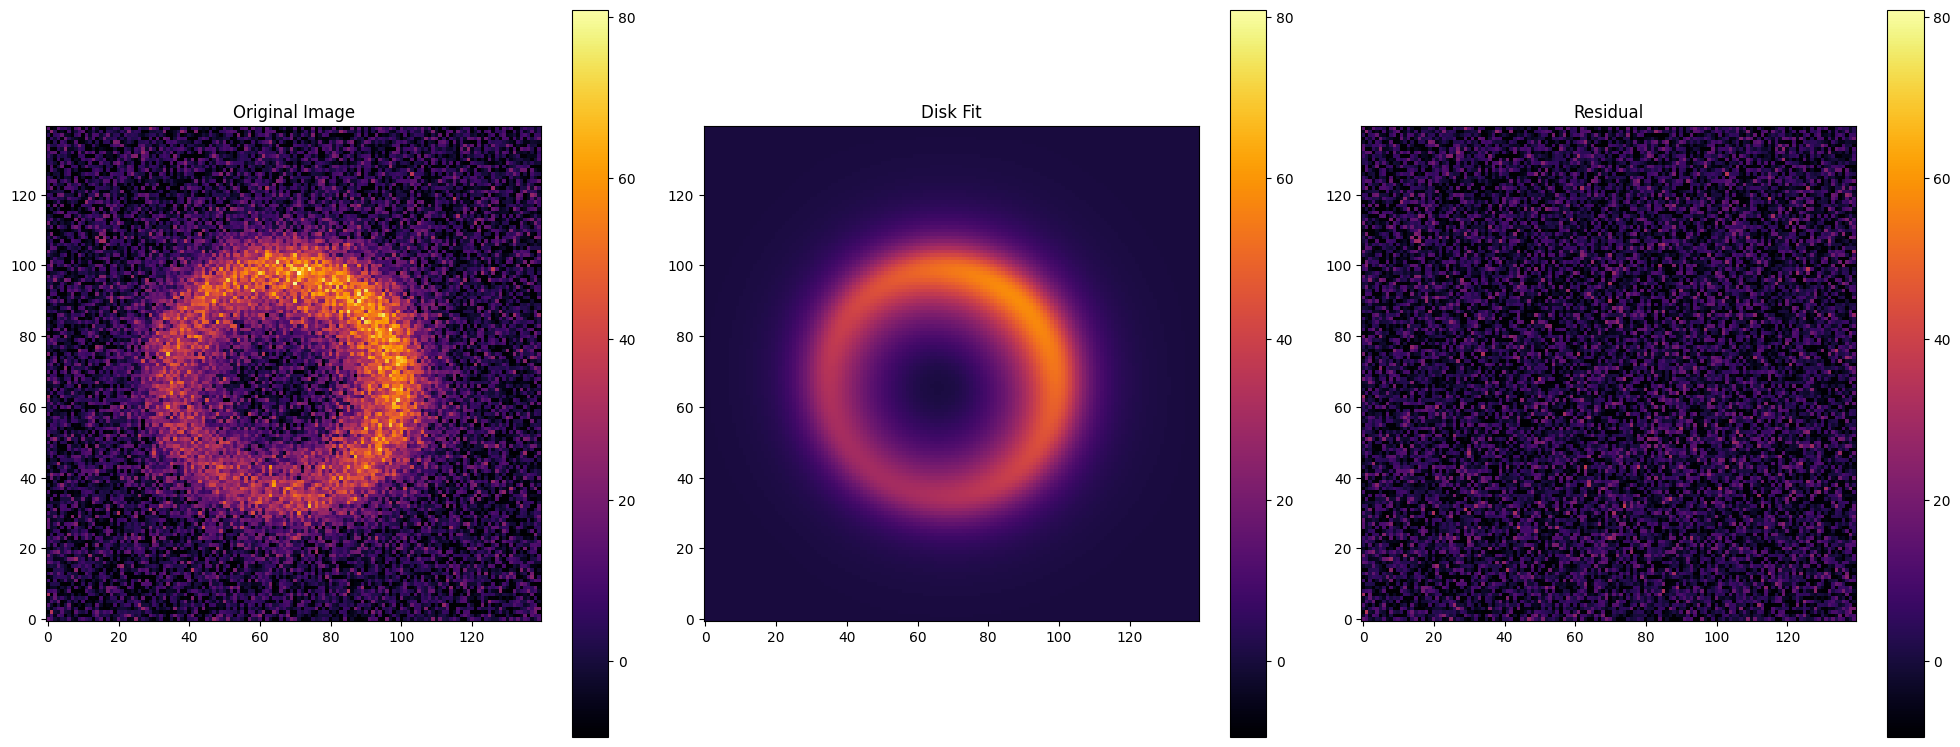

In [ ]:
mc_model.set_discarded_iters(500)
opt.scale_spline_to_fixed_point(0, 1)
opt.print_params()
target_image = target_img
fig, axes = plt.subplots(1,3, figsize=(20,10))

mask = OptimizeUtils.get_mask(target_image)
vmin = np.nanpercentile(target_image, 10)
vmax = np.nanpercentile(target_image, 100)

im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
axes[0].set_title("Original Image")
plt.colorbar(im, ax=axes[0], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
axes[1].set_title("Disk Fit")
plt.colorbar(im, ax=axes[1], shrink=0.75)
im.set_clim(vmin, vmax)

im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
axes[2].set_title("Residual")
plt.colorbar(im, ax=axes[2], shrink=0.75)
im.set_clim(vmin, vmax)

plt.tight_layout()
plt.savefig('{}_mcmc_img.png'.format(name))

In [ ]:
print(np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params))))

[ 71.61472669  80.92642983  90.          99.07357017 108.38527331]


In [ ]:
print(opt.spf_params)

{'backscatt_bound': Array(-0.31540514, dtype=float64, weak_type=True), 'forwardscatt_bound': Array(0.31540514, dtype=float64, weak_type=True), 'num_knots': 5, 'knot_values': Array([1.69985012, 1.25952017, 1.        , 0.76213582, 0.56947605],      dtype=float64), 'frontscatt_bound': 0.9}


(2267, 100, 9)


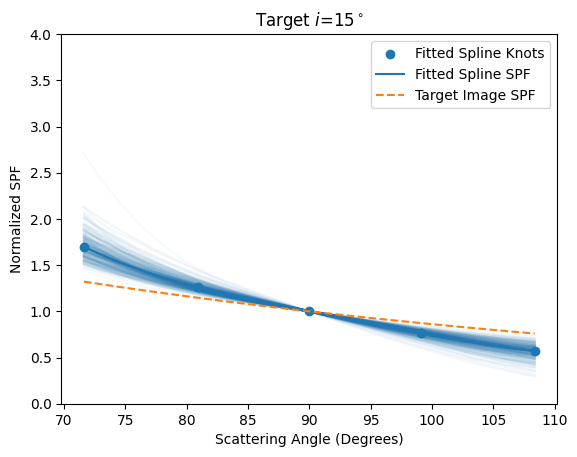

In [ ]:
knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.plot(x_vals,InterpolatedUnivariateSpline_SPF.pack_pars([4.0,2.0,1.0,0.5,0.1],knots=np.linspace(0,180,5))(x_vals),zorder=10,linestyle='dashed')
for i in np.random.random(300)*(len(mc_model.scaled_chain)-500):
    j = int(np.random.random()*100)
    i = int(i)+500
    kvals = mc_model.scaled_chain[i,j,4:]
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals)/InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(90),color='tab:blue',alpha=0.03)
plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
plt.ylim(0,4)
#plt.xlim(knot_locs[0]-5, knot_locs[-1]+5)
plt.xlabel('Scattering Angle (Degrees)')
plt.ylabel('Normalized SPF')
plt.title("Target $i$={}$^\circ$".format(inc))
print(mc_model.scaled_chain.shape)
plt.savefig('{}_mcmc_spf.png'.format(name))

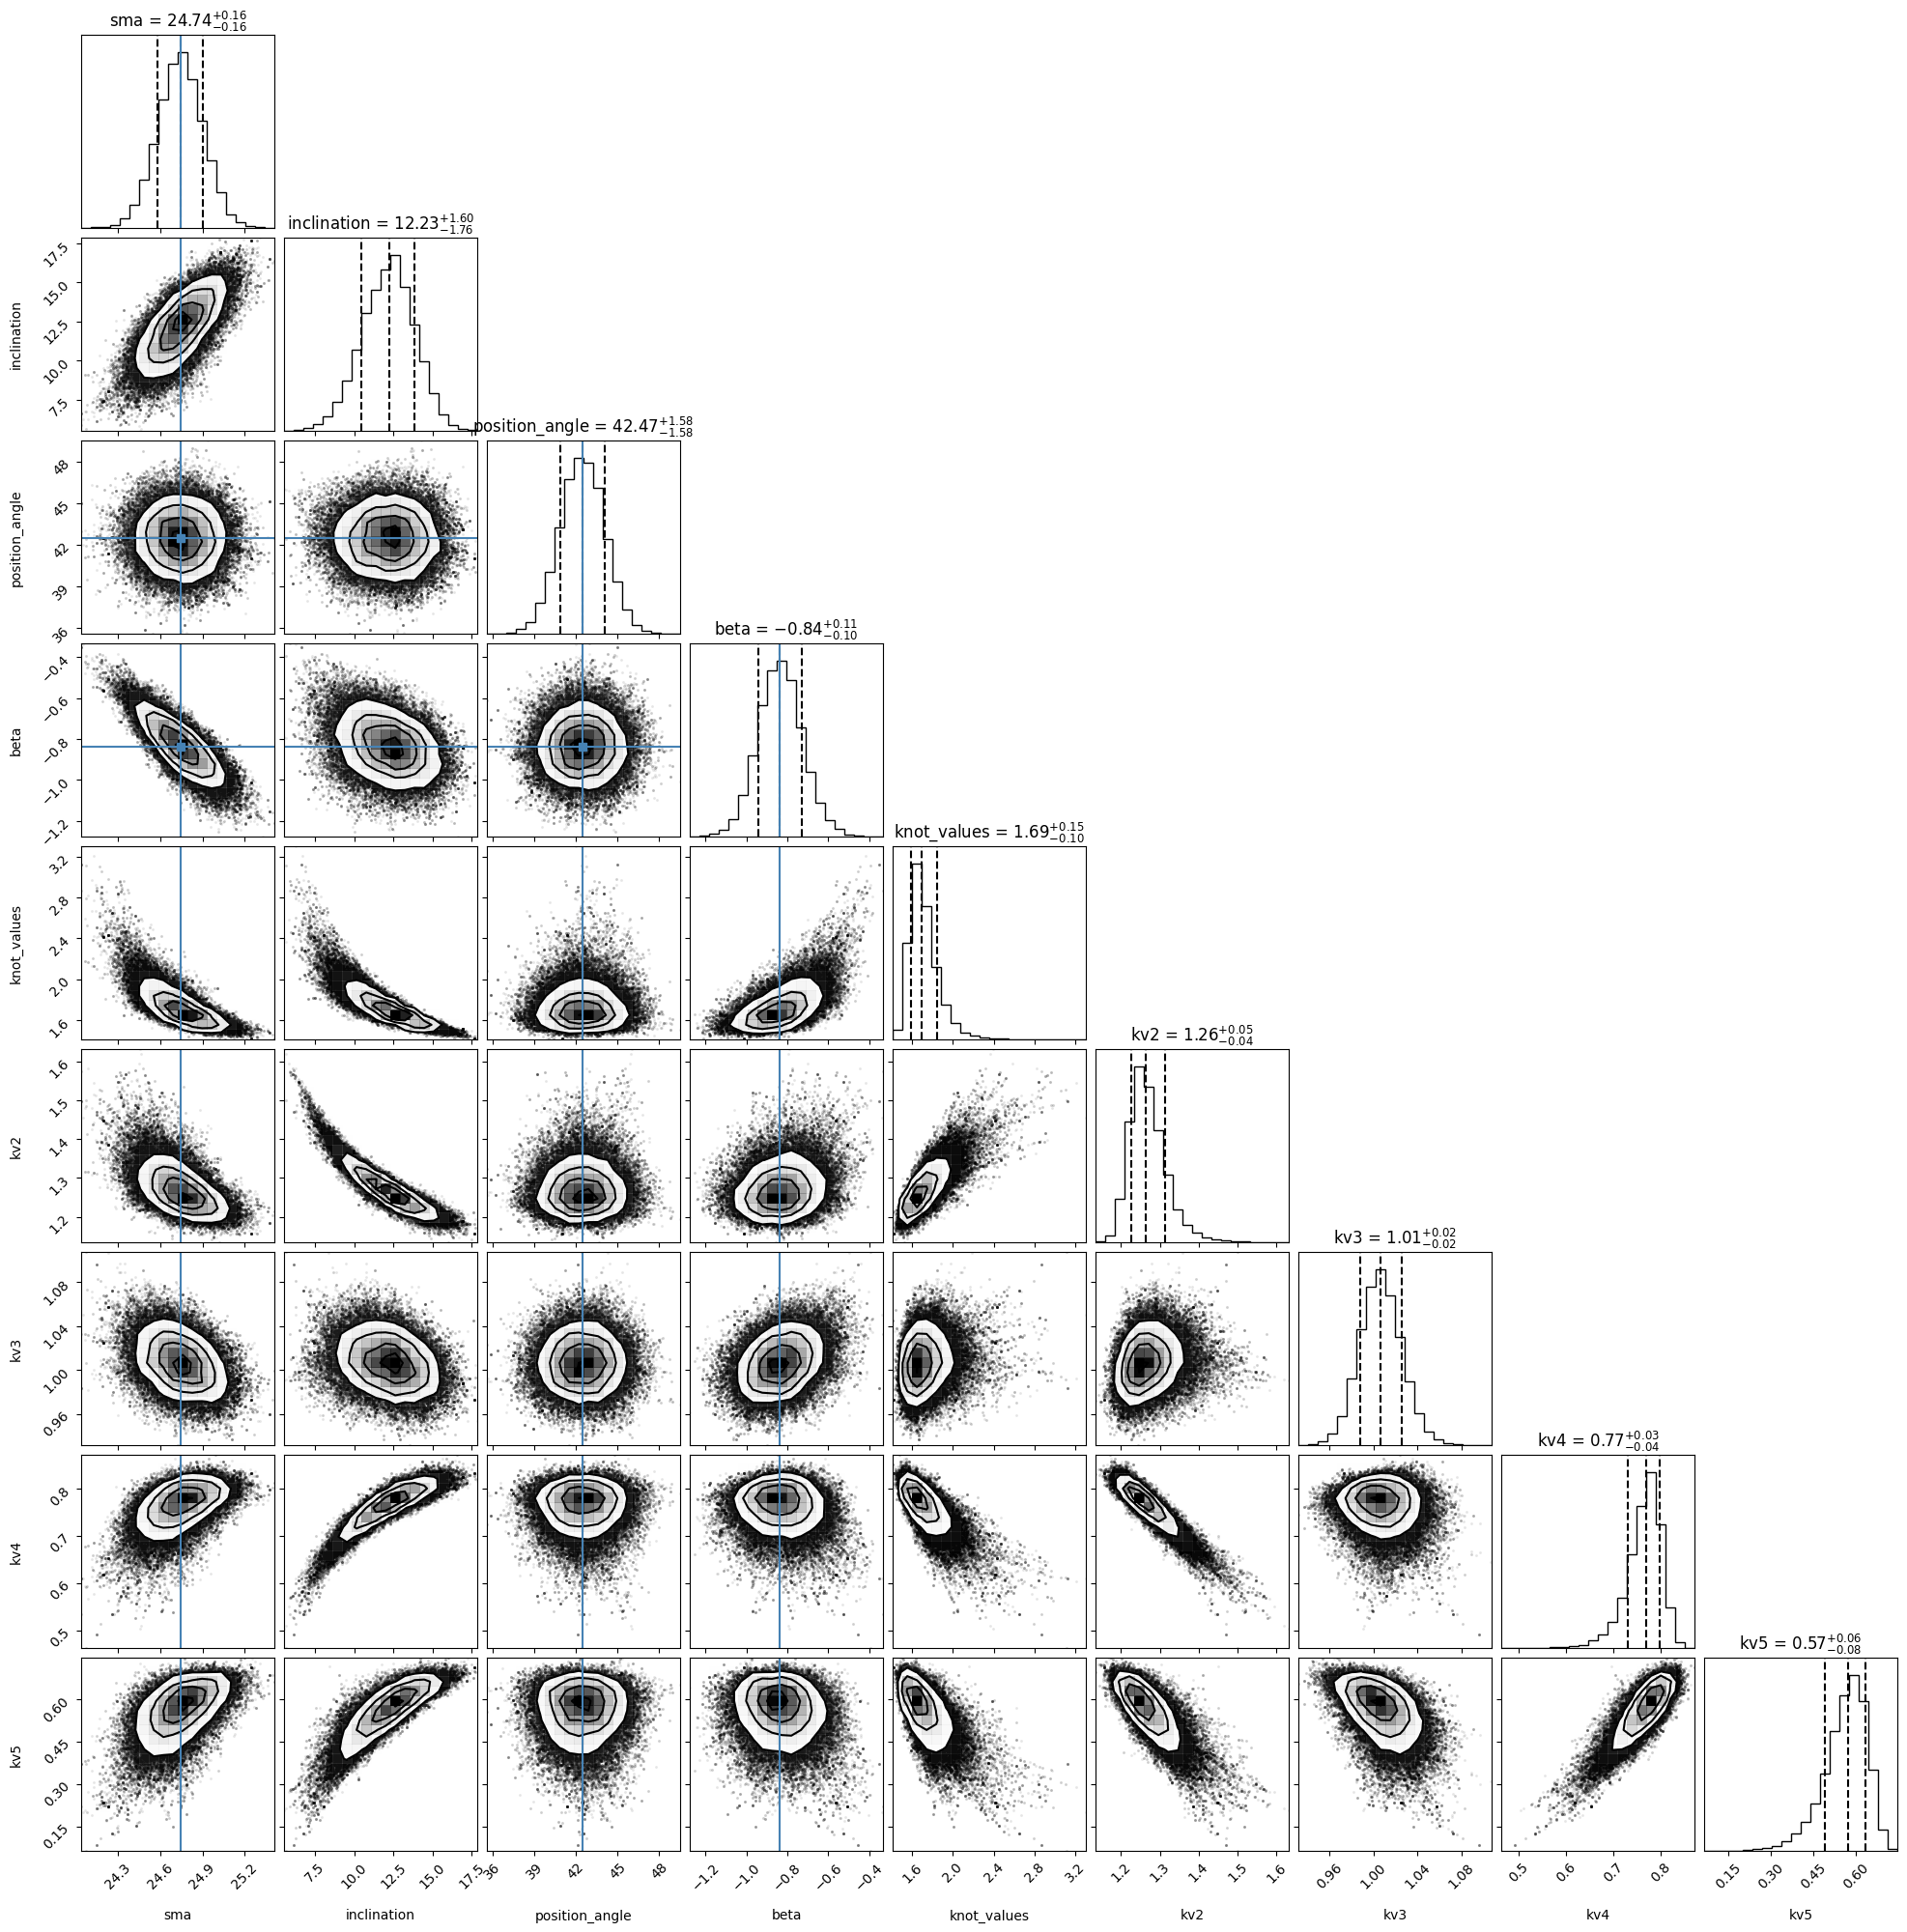

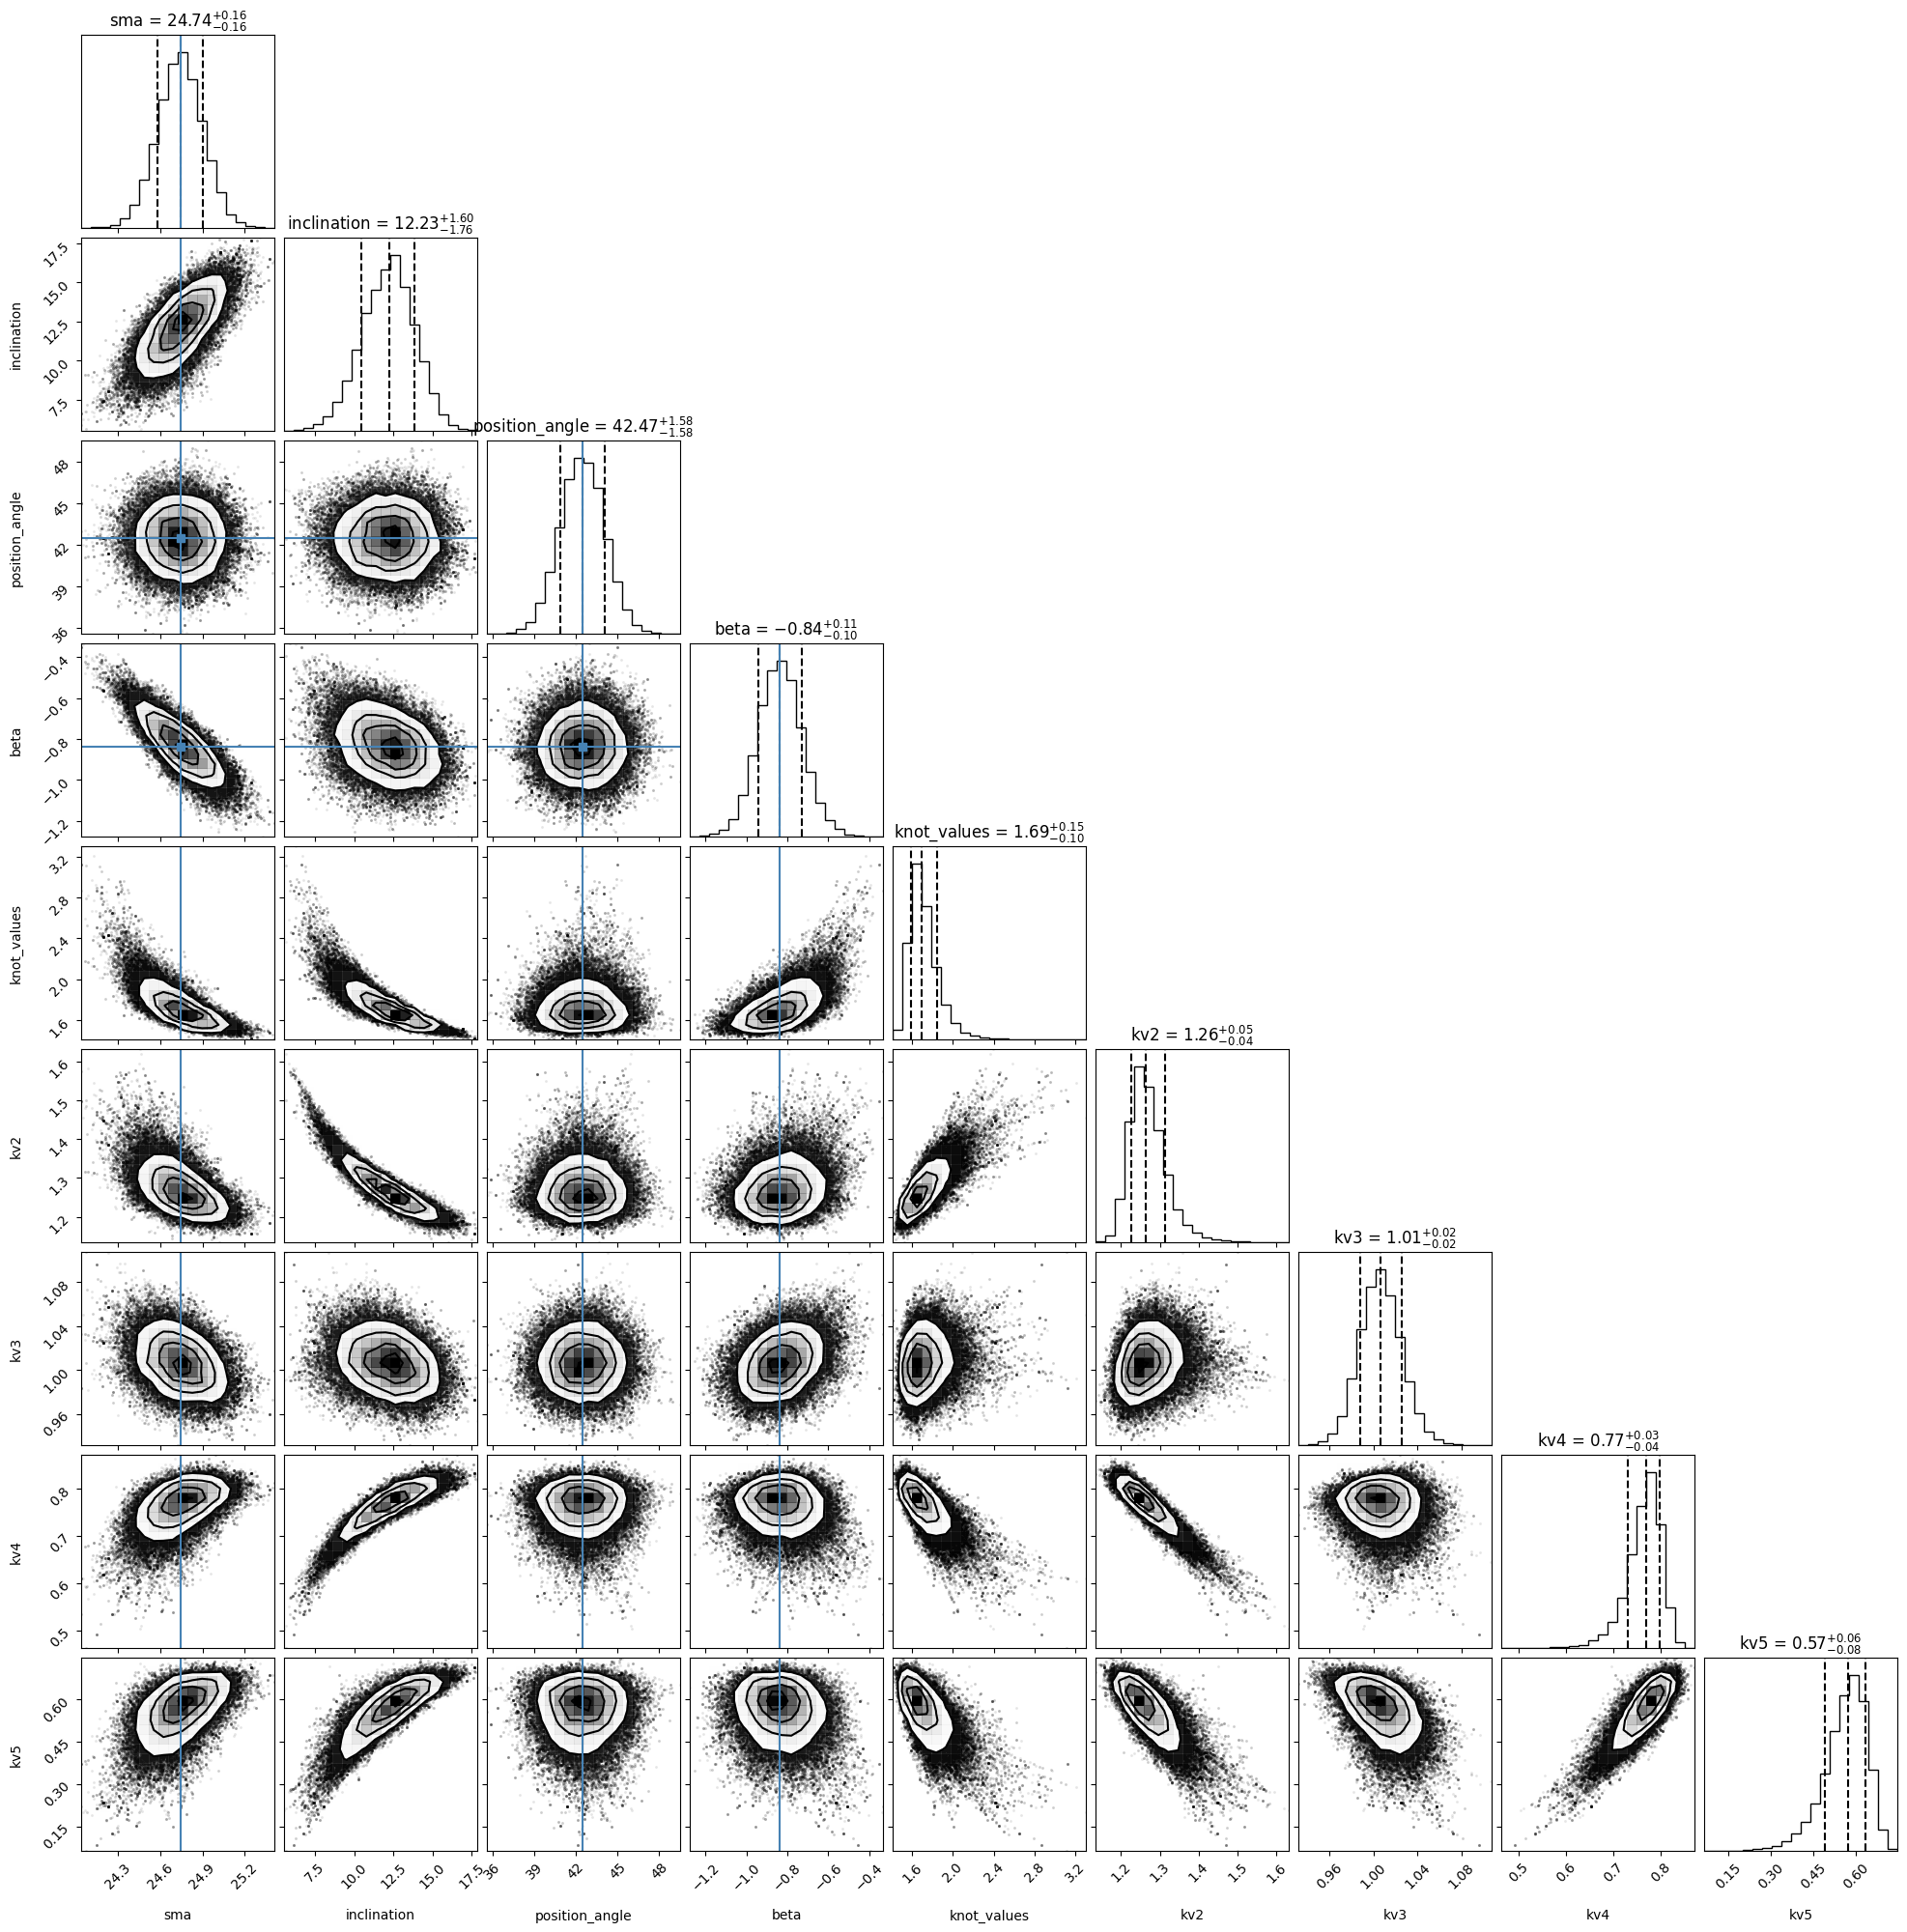

In [ ]:
mc_soln = mc_model.get_theta_median()
mc_model.show_corner_plot(fit_keys+['kv2','kv3','kv4','kv5'], truths=mc_soln, scaled=True)

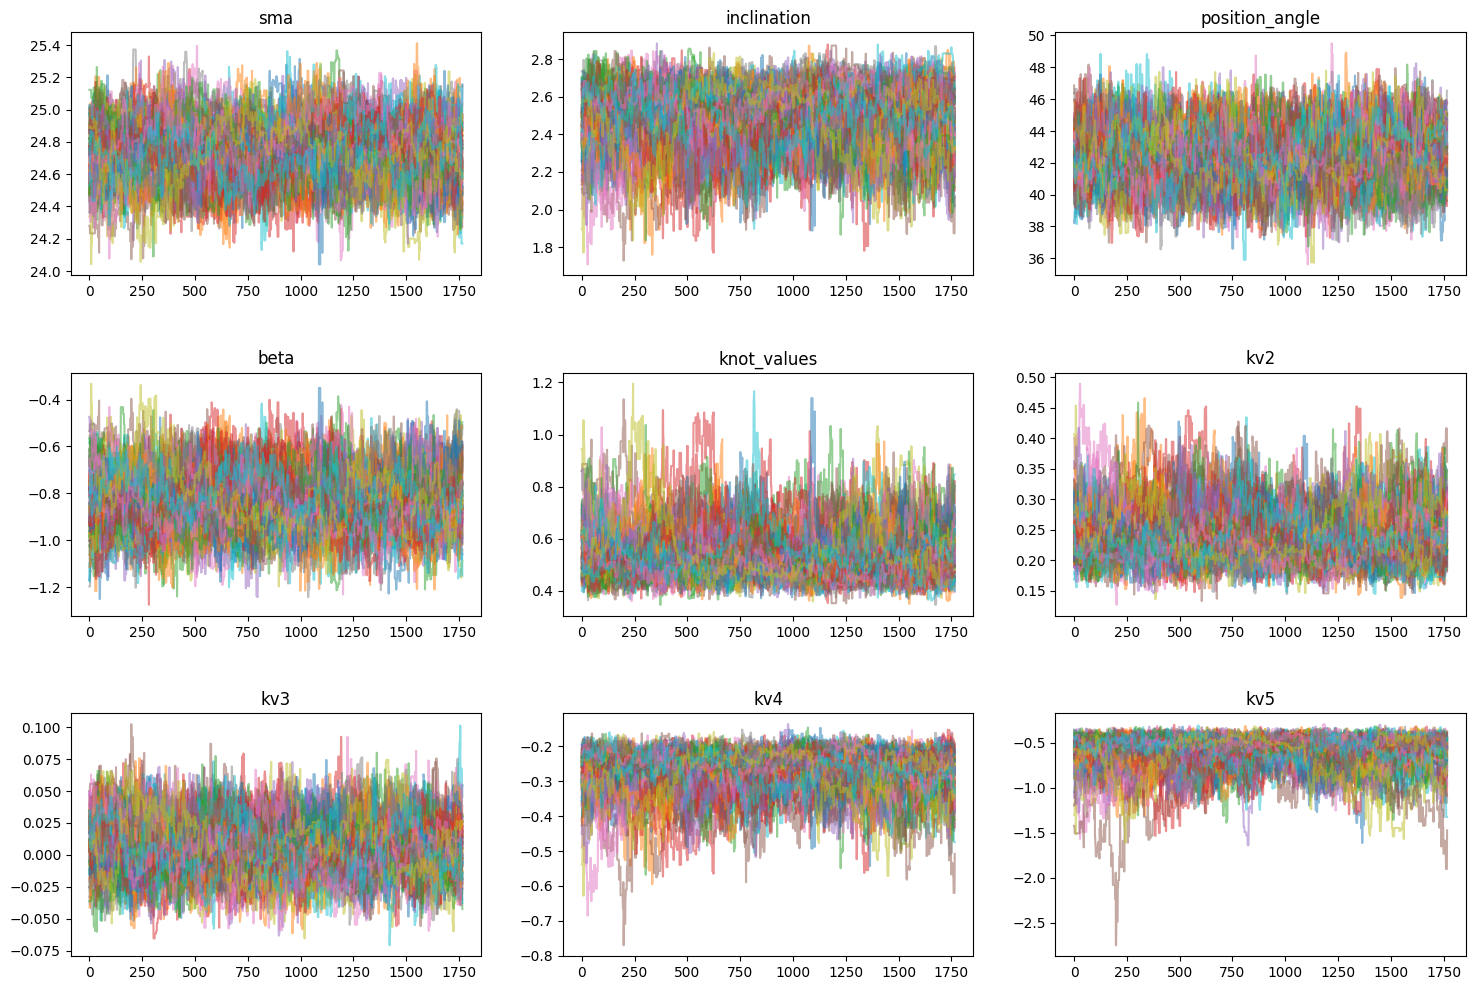

In [ ]:
mc_model.plot_chains(fit_keys+['kv2','kv3','kv4','kv5'])

In [ ]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("../docs/tutorials/tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 28
start_disk_params['position_angle'] = 48
start_disk_params['beta'] = 0.5

'''
def recover_disk(injected_disk):
    target_img = jnp.array(fits.getdata(injected_disk))
    err_map = jnp.ones(target_img.shape)*10
    start_disk_params['inclination'] = float(injected_disk.split("_")[2][3:4])
    spf_num = float(injected_disk.split("_")[3][3])
    if spf_num == 0:
        spf_truth = [4.0,2.0,1.0,0.5,0.1]
    elif spf_num == 1:
        spf_truth = [8.0,4.0,1.0,0.2,0.4]
    elif spf_num == 2:
        spf_truth = [2.0,3.0,2.0,1.0,0.5]
    opt = Optimizer(ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF,
                start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params)
    opt.inc_bound_knots() # call this method only if you have a good predifined inclination, otherwise don't use it
    opt.set_empirical_psf(emp_psf_image) # <-- Only necessary if you have an empirical_psf_image
    opt.initialize_knots(target_img) # <-- This needs to be called first before any modeling or jit compiling if spline spf is being used

    #scipy minimize
    fit_keys = ['sma', 'inclination', 'position_angle', 'e','beta','knot_values']
    logscaled_params = ['knot_values']
    array_params = ['knot_values']
    bounds = ([0, 0, 0,0,-5, np.zeros(opt.spf_params["num_knots"])],
            [150, 180, 400,  1,5,1e4*np.ones(opt.spf_params["num_knots"])])

    opt.scipy_bounded_optimize(fit_keys, bounds, logscaled_params, array_params, target_img, err_map, use_grad = True, disp_soln = True, iters = 2000)
    optimal_image = opt.get_model()

    opt.scale_spline_to_fixed_point(0, 1)
    opt.print_params()
    target_image = target_img
    fig, axes = plt.subplots(1,3, figsize=(20,10))

    mask = OptimizeUtils.get_mask(target_image)
    vmin = np.nanpercentile(target_image[mask], 10)
    vmax = np.nanpercentile(target_image[mask], 95)

    im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
    axes[0].set_title("Original Image")
    plt.colorbar(im, ax=axes[0], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
    axes[1].set_title("Disk Fit")
    plt.colorbar(im, ax=axes[1], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
    axes[2].set_title("Residual")
    plt.colorbar(im, ax=axes[2], shrink=0.75)
    im.set_clim(vmin, vmax)

    plt.tight_layout
    plt.savefig('{}_scipyminimize_img.png'.format(name))

    knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
    x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
    plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(knot_locs))
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(x_vals))
    plt.scatter(knot_locs,spf_truth,marker='x',zorder=10)

    plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
    plt.savefig('{}_scipyminimize_spf.png'.format(name))

    ##MCMC
    mc_model = opt.mcmc(fit_keys, logscaled_params, array_params, target_image, err_map, bounds, nwalkers=100, niter=2000, burns=500)
    mc_model.set_discarded_iters(500)
    opt.scale_spline_to_fixed_point(0, 1)
    opt.print_params()
    target_image = target_img
    fig, axes = plt.subplots(1,3, figsize=(20,10))

    mask = OptimizeUtils.get_mask(target_image)
    vmin = np.nanpercentile(target_image[mask], 10)
    vmax = np.nanpercentile(target_image[mask], 95)

    im = axes[0].imshow(target_image, origin='lower', cmap='inferno')
    axes[0].set_title("Original Image")
    plt.colorbar(im, ax=axes[0], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[1].imshow(optimal_image, origin='lower', cmap='inferno')
    axes[1].set_title("Disk Fit")
    plt.colorbar(im, ax=axes[1], shrink=0.75)
    im.set_clim(vmin, vmax)

    im = axes[2].imshow(target_image-optimal_image, origin='lower', cmap='inferno')
    axes[2].set_title("Residual")
    plt.colorbar(im, ax=axes[2], shrink=0.75)
    im.set_clim(vmin, vmax)

    plt.tight_layout()
    plt.savefig('{}_mcmc_img.png'.format(name))

    knot_locs = np.rad2deg(np.arccos(InterpolatedUnivariateSpline_SPF.get_knots(opt.spf_params)))
    x_vals = jnp.linspace(knot_locs[0], knot_locs[-1], 200)
    plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(knot_locs))
    plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(opt.spf_params['knot_values'],
                        knots=knot_locs)(x_vals))
    plt.scatter(knot_locs,spf_truth,marker='x',zorder=10)
    for i in np.random.random(100)*(len(mc_model.scaled_chain)-500):
        j = int(np.random.random()*100)
        i = int(i)+500
        kvals = mc_model.scaled_chain[i,j,9:]
        plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(x_vals)/InterpolatedUnivariateSpline_SPF.pack_pars(kvals,knots=knot_locs)(90),color='tab:blue',alpha=0.2)
    plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])
    plt.ylim(0,10)

    plt.savefig('{}_mcmc_spf.png'.format(name))

    print('for disk {}'.format(injected_disk),'beta is', opt.disk_params['beta'])

'''

In [ ]:
recover_disk("inject_disk_inc0_spf0_betaneg.fits")